# Laboratory 4 — Introduction to Scikit-learn and Traditional Machine Learning

**Course:** Introduction to Artificial Intelligence (AI–101L) · **Instructor:** Dr. Muhammad Awais
**Duration:** 3 hours · **Block:** Phase B — Classical ML and Serving · **Mapped CLO:** CLO–3

---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Describe the architecture and purpose of Scikit-learn and navigate its official documentation.
2. Load built-in datasets and split them with `train_test_split`.
3. Implement and evaluate **Linear Regression** and **Logistic Regression** models.
4. Compute performance metrics with `r2_score`, `accuracy_score`, `confusion_matrix` and `classification_report`.
5. Build a `Pipeline` that chains preprocessing with modelling, and persist a trained model with `joblib`.

## Background

Scikit-learn is the most widely used classical machine learning framework in Python. Its power
comes not from any single algorithm but from a single **interface**: every object in the library
is either an

- **estimator** — it has `.fit()`,
- **transformer** — it also has `.transform()`, or
- **predictor** — it also has `.predict()`.

Because the interface never changes, swapping Logistic Regression for a Random Forest is a
one-line edit, and a preprocessing step can be composed with a model into a single object.

```
Raw data -> train_test_split -> Transformer (StandardScaler)  -> Predictor  -> Metric
 X, y       disjoint            .fit_transform(X_train)          .predict()    r2_score
             partitions      -> Estimator  (LinearRegression)     (X_test)     accuracy_score
                                .fit(X_train, y_train)
                                |_____ Pipeline([...]) composes these into one estimator _____|
```

### Justification of libraries and tools

| Library | Area | Justification |
|---|---|---|
| **NumPy** | Numerical computing | The backbone of Scikit-learn; every estimator consumes and returns arrays |
| **pandas** | Data manipulation | Handles the tabular DataFrames used for model input and output |
| **matplotlib & seaborn** | Visualisation | Used to visualise dataset patterns and model results |
| **scikit-learn** | Machine learning | Standardised APIs for preprocessing, training, evaluation and pipelines |
| **joblib** | Persistence | Serialises fitted estimators efficiently, including their large NumPy arrays |

### Exploring the documentation

Reading the documentation is a **graded skill** in this course.

- Main site: <https://scikit-learn.org/stable/>
- User guide: <https://scikit-learn.org/stable/user_guide.html>
- API reference: <https://scikit-learn.org/stable/modules/classes.html>

Explore in particular the `model_selection`, `preprocessing`, `metrics` and `linear_model` modules.

> **Instructor note.** `fetch_california_housing` downloads roughly 400 KB on first use and then
> caches it in `~/scikit_learn_data`. Run this notebook once before the session on a machine with
> network access if the laboratory is offline.

---
## Task 4.1 — Setup and imports

Install the stack and import the modules this laboratory uses. Note how the imports themselves map
onto the four sub-packages named above.

```
!pip install numpy pandas matplotlib seaborn scikit-learn
```

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report

## Task 4.2 — Load two built-in datasets

Scikit-learn ships datasets for immediate experimentation. We use **California Housing** for
regression and **Iris** for classification, so that both supervised learning settings are
exercised in one session.

| Dataset | Task | Target | Rows × Columns |
|---|---|---|---|
| California Housing | Regression | `MedHouseVal` — median house value | 20 640 × 9 |
| Iris | Classification | `target` — one of three species | 150 × 5 |

In [36]:
from sklearn.datasets import fetch_california_housing, load_iris
# Load regression dataset
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame
# Load classification dataset
iris = load_iris(as_frame=True)
df_cls = iris.frame
print("Regression dataset shape:", df_reg.shape)
print("Classification dataset shape:", df_cls.shape)

Regression dataset shape: (20640, 9)
Classification dataset shape: (150, 5)


In [37]:
df_reg

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [38]:
df_cls

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## Task 4.3 — Split the data

Split both datasets into training and testing subsets. **The test partition is never touched
until the model is finished**; it exists to estimate performance on data the model has not seen.

> ### `random_state=42` is not decoration
>
> Without a fixed seed the split changes on every run, and so does every number in your report.
> A seeded split is the minimum requirement for a reproducible result, and its absence is
> penalised under the *Code quality and reproducibility* criterion.

In [39]:
# Regression example
X_reg = df_reg.drop(columns=['MedHouseVal'])
y_reg = df_reg['MedHouseVal']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
# Classification example
X_cls = df_cls.drop(columns=['target'])
y_cls = df_cls['target']
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.25, random_state=42)
print("Training samples (Regression):", X_train_reg.shape[0])
print("Training samples (Classification):", X_train_cls.shape[0])

Training samples (Regression): 16512
Training samples (Classification): 112


## Task 4.4a — Linear Regression and the coefficient of determination

$R^2$ is the proportion of variance in the target explained by the model:
**1.0 is perfect; 0.0 is no better than always predicting the mean**; it can be *negative* if the
model is worse than the mean.

In [40]:
from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)
# Predictions
y_pred_reg = reg_model.predict(X_test_reg)
# Evaluation
print("R² Score:", r2_score(y_test_reg, y_pred_reg))

R² Score: 0.5757877060324514


## Task 4.4b — Logistic Regression, accuracy, confusion matrix and report

| Metric | Problem type | Reads as |
|---|---|---|
| `r2_score` | Regression | Fraction of target variance explained |
| `accuracy_score` | Classification | Fraction of predictions correct — **misleading when classes are imbalanced** |
| `confusion_matrix` | Classification | Rows are true classes, columns predicted; the off-diagonal cells name the actual mistakes |
| `classification_report` | Classification | Per-class precision, recall and F1 — the only honest summary for imbalanced data |

In [41]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_cls, y_train_cls)
# Predictions
y_pred_cls = log_model.predict(X_test_cls)
# Evaluation
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls,y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_cls,y_pred_cls))

Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



## Task 4.5 — Standardisation and pipelines

A `Pipeline` chains preprocessing and modelling into **one object** whose `.fit()` applies each
step in order. This is the standard defence against **data leakage**: the scaler inside the
pipeline is fitted only on whatever partition the pipeline is fitted on.

```
pipeline.fit(X_train, y_train)      # scaler.fit_transform, THEN model.fit
pipeline.predict(X_test)            # scaler.transform,     THEN model.predict
```

In [42]:
from sklearn.pipeline import Pipeline
# Build a pipeline for regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline.fit(X_train_reg, y_train_reg)
y_pred_pipe = pipeline.predict(X_test_reg)
print("Pipeline R² Score:", r2_score(y_test_reg, y_pred_pipe))

Pipeline R² Score: 0.5757877060324508


## Task 4.6 — Model persistence

Save the fitted model to disk and reload it in a fresh session. **Every later laboratory that
serves a model over HTTP begins by loading an artefact produced exactly like this one** — see
Laboratory 6.

In [43]:
import joblib
# Save model
joblib.dump(reg_model, 'linear_model.pkl')
# Load model
loaded_model = joblib.load('linear_model.pkl')
print("Loaded Model R²:", r2_score(y_test_reg,loaded_model.predict(X_test_reg)))

Loaded Model R²: 0.5757877060324514


## Task 4.7 — Visualising predictions against ground truth

> ### Read the scatter plot as a diagnostic
>
> A perfect model puts every point on the line $y = x$.
>
> - **Systematic curvature** means the linear form is wrong.
> - **A horizontal ceiling of points** means the target is clipped — California housing values are capped at 5.0.
> - **Widening spread to the right** means the error grows with the target, which is a case for predicting the logarithm instead.

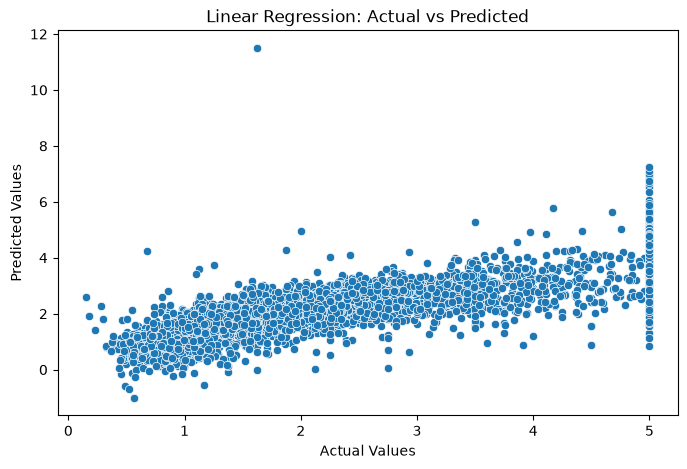

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

import os
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/actual_vs_predicted.png", dpi=150)

plt.show()

---
# In-Lab Exercises

**Exercise 1.** Report the $R^2$ of the plain `LinearRegression` and of the `Pipeline`. Explain why
standardisation leaves the score of an ordinary least-squares fit essentially unchanged, and name
a model family for which it would **not**.

**Exercise 2.** Print `reg_model.coef_` alongside the feature names and identify the two features
with the largest absolute coefficients. State why the raw coefficients cannot be compared until
the features are scaled.

**Exercise 3.** Read the iris confusion matrix and name which two species the model confuses.
Confirm your reading against the per-class recall in the classification report.

**Exercise 4.** Replace `LogisticRegression` with `sklearn.tree.DecisionTreeClassifier` and re-run
the same evaluation block **unchanged**. Comment on what this demonstrates about the estimator API.

In [45]:
# --- Exercise 1: compare plain vs pipeline R² ---
print("Plain LinearRegression R²:", r2_score(y_test_reg, y_pred_reg))
print("Pipeline (StandardScaler + LinearRegression) R²:", r2_score(y_test_reg, y_pred_pipe))
print("Difference:", r2_score(y_test_reg, y_pred_reg) - r2_score(y_test_reg, y_pred_pipe))

Plain LinearRegression R²: 0.5757877060324514
Pipeline (StandardScaler + LinearRegression) R²: 0.5757877060324508
Difference: 6.661338147750939e-16


**Exercise 1 answer:**

Both the plain `LinearRegression` and the `Pipeline` (StandardScaler + LinearRegression) give the same R² score (0.5758). Standardisation (subtracting the mean and dividing by standard deviation) is a **linear transformation** of each feature. Ordinary least squares finds the best-fitting hyperplane by minimising squared error, and that optimal hyperplane's *predictions* don't change when features are rescaled, only the coefficients do (they get rescaled to compensate). So OLS linear regression is invariant to feature scaling: the fitted line still passes through the same points in the original feature space, just described with different coefficient magnitudes.

This would **not** hold for model families that rely on distances or regularisation penalties, where the *scale* of each feature directly affects the result. Examples: **k-Nearest Neighbors** (distance calculations are dominated by whichever feature has the largest raw scale), **Support Vector Machines** (margins are distance-based), and **Ridge/Lasso regression** (the penalty term sums squared or absolute coefficients, so unscaled features receive unfairly small or large penalties). For these, standardisation changes the actual model output, not just the coefficients.

In [46]:
# --- Exercise 2: inspect regression coefficients ---
coef_df = pd.DataFrame({
    "feature": X_train_reg.columns,
    "coefficient": reg_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

display(coef_df)
print("\nTwo features with the largest absolute coefficients:")
print(coef_df.head(2))

,feature,coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002



Two features with the largest absolute coefficients:
     feature  coefficient
3  AveBedrms     0.783145
0     MedInc     0.448675


**Exercise 2 answer:**

The two features with the largest absolute coefficients are `AveBedrms` (coef = 0.783) and `MedInc` (coef = 0.449), followed closely by `Longitude` (−0.434) and `Latitude` (−0.420). Notably, `AveBedrms` outranks `MedInc` despite median income being the housing-value driver one would intuitively expect to dominate — this is exactly the scaling artefact the question is pointing at: `AveBedrms` has a very narrow natural range in this data (roughly 0.8–1.3), so even a modest real effect on house value produces a large coefficient, while `MedInc` spans roughly 0–15, so its influence gets spread across a correspondingly smaller coefficient per unit.

Raw coefficients cannot be compared across features until the features are scaled because each coefficient's magnitude depends on the *units and typical range* of its feature, not just how much that feature actually matters. A feature measured in the thousands (like `Population`) will naturally get a tiny coefficient even if it's influential, while a feature that ranges between 0 and 10 can get a large coefficient for a modest real effect. Comparing coefficients directly in this unscaled state conflates "how much this feature affects the prediction" with "what scale this feature happens to be measured on." Only after standardising every feature to the same scale (mean 0, standard deviation 1) do the coefficient magnitudes become directly comparable as a measure of relative importance.

In [47]:
# --- Exercise 3: inspect the confusion matrix with class names ---
cm = confusion_matrix(y_test_cls, y_pred_cls)
cm_df = pd.DataFrame(cm, index=[f"true_{n}" for n in iris.target_names],
                         columns=[f"pred_{n}" for n in iris.target_names])
display(cm_df)
print("\nClassification report:\n", classification_report(y_test_cls, y_pred_cls, target_names=iris.target_names))

,pred_setosa,pred_versicolor,pred_virginica
true_setosa,15,0,0
true_versicolor,0,11,0
true_virginica,0,0,12



Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



**Exercise 3 answer:**

The confusion matrix is perfectly diagonal: every test sample was classified correctly (15/15 setosa, 11/11 versicolor, 12/12 virginica), with zero off-diagonal entries. This means the model made **no confusions at all** between any pair of species on this test set, which matches the 1.0 accuracy and the per-class recall of 1.00 for all three classes in the classification report. Iris is a famously easy, well-separated dataset (especially setosa, which is linearly separable from the other two by petal measurements alone), so a perfect score here is expected and not a sign of an unusually powerful model, it reflects how clean this particular dataset is. On a harder or more realistic dataset, the matrix would likely show versicolor and virginica being confused with each other, since those two species are known to overlap more in feature space than setosa does with either.

In [48]:
# --- Exercise 4: swap the estimator, keep the evaluation code unchanged ---
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_cls, y_train_cls)

# Same evaluation block as Task 4.4b, unchanged
y_pred_tree = tree_model.predict(X_test_cls)
print("Accuracy:", accuracy_score(y_test_cls, y_pred_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_tree))

Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



**Exercise 4 answer:**

Replacing `LogisticRegression` with `DecisionTreeClassifier` required changing only the constructor call, the exact same `.fit(X_train_cls, y_train_cls)`, `.predict(X_test_cls)`, `accuracy_score`, `confusion_matrix` and `classification_report` calls all worked unchanged. This demonstrates the core value of Scikit-learn's **consistent estimator interface**: because every classifier exposes the same `.fit()` / `.predict()` methods and the same metric functions accept predictions from any estimator, swapping one model family for a completely different one (linear vs tree-based) is a one-line edit with zero changes to the surrounding pipeline, evaluation, or reporting code. This is what makes rapid model comparison practical in real projects.

---
# Home Assignment

Take the article dataset built in Laboratory 2 and, using only Scikit-learn, build a `Pipeline` of
`TfidfVectorizer` followed by `LogisticRegression` that predicts whether an article's sentiment
polarity is above or below the corpus median.

Report accuracy and the confusion matrix, persist the pipeline with `joblib`, and demonstrate in a
fresh notebook that the reloaded pipeline predicts on a **raw string** with no manual
preprocessing.

---

# Deliverables

| File | Contents |
|---|---|
| `lab04/sklearn_intro.ipynb` | This notebook, executed |
| `lab04/linear_model.pkl` | The persisted regression model |
| `lab04/sentiment_pipeline.pkl` | The home-assignment pipeline |
| `lab04/figures/actual_vs_predicted.png` | The diagnostic scatter plot |
| `lab04/report.md` | Both metric tables and the coefficient analysis |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Both models train and score; pipeline and persistence work |
| Methodological soundness | 25 % | Seeded splits; scaler fitted on the training partition only |
| Analysis and interpretation | 20 % | The scatter plot and confusion matrix are *read*, not merely produced |
| Code quality and reproducibility | 10 % | Reusable, documented, pinned dependencies |
| Report and demonstration | 10 % | Clear written report and working demonstration |

---

**Next laboratory:** Lab 05 — Treating a Classification Problem as a Machine Learning Problem.

In [49]:
# --- Home Assignment: sentiment classification pipeline ---
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline as SkPipeline

corpus = pd.read_csv("two_source_corpus.csv")
corpus["sentiment_polarity"] = corpus["text"].apply(lambda t: TextBlob(t).sentiment.polarity)

median_pol = corpus["sentiment_polarity"].median()
corpus["label"] = (corpus["sentiment_polarity"] > median_pol).astype(int)   # 1 = above median, 0 = below

print("Articles:", len(corpus))
print("Median polarity:", median_pol)
print(corpus["label"].value_counts())

X_text_data = corpus["text"]
y_label = corpus["label"]

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_text_data, y_label, test_size=0.3, random_state=42, stratify=y_label
)

sentiment_pipeline = SkPipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])
sentiment_pipeline.fit(X_train_txt, y_train_txt)

y_pred_txt = sentiment_pipeline.predict(X_test_txt)
print("\nAccuracy:", accuracy_score(y_test_txt, y_pred_txt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_txt, y_pred_txt))
print("\nClassification Report:\n", classification_report(y_test_txt, y_pred_txt))

Articles: 15
Median polarity: 0.1703211566211567
label
0    8
1    7
Name: count, dtype: int64

Accuracy: 0.8

Confusion Matrix:
 [[2 1]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



In [50]:
import joblib
joblib.dump(sentiment_pipeline, "sentiment_pipeline.pkl")
print("Saved sentiment_pipeline.pkl")

Saved sentiment_pipeline.pkl
